# Notebook 5 — Final Real/Fake fusion benchmark

This notebook compares ten fusion approaches using exactly three probability features. It creates a single **70% development / 30% untouched final-test** split, performs all model and threshold selection with **stratified 5-fold CV on development only**, then refits one selected configuration and evaluates the final test once.

Leakage controls:

- related `source / generator` groups stay together when audit metadata is available;
- scaling, splines, calibration, hyperparameter search, and weight fitting occur on training data only;
- fold validation labels are used only for evaluation;
- final-test labels are not accessed until the last evaluation cell.

The two SVM kernels are reported separately, so the ten requested approach families produce **11 result labels**.

## 1. Imports and configuration

In [21]:
from pathlib import Path
import json, os, warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.optimize import minimize
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.frozen import FrozenEstimator
from sklearn.kernel_approximation import Nystroem
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    brier_score_loss, confusion_matrix, f1_score, log_loss,
    matthews_corrcoef, precision_recall_curve, precision_score,
    recall_score, roc_auc_score, roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV, GroupShuffleSplit, StratifiedGroupKFold,
    StratifiedKFold, train_test_split,
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, SplineTransformer, StandardScaler
from sklearn.svm import SVC

from xgboost import XGBClassifier

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "modeling").exists():
    candidate = PROJECT_ROOT / "Coding"
    PROJECT_ROOT = candidate if candidate.exists() else PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)

SEED = 1337
N_FOLDS = 5
THRESHOLDS = np.array([0.1, 0.3, 0.5, 0.7, 0.9])
EPS = 1e-7
N_JOBS = -1
DATA_PATH = PROJECT_ROOT / "outputs/meta_fusion/meta_training_2000.csv"
AUDIT_PATH = PROJECT_ROOT / "outputs/meta_fusion/meta_training_2000_audit.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs/meta_fusion/notebook05_benchmark"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_COLUMNS = [
    "Community Forensics Pr",
    "DINOv3-L detector Pr",
    "DINOv3-B stacking detector Pr",
]
TARGET_CANDIDATES = ["Real/Fake image", "Real/Fake image (0/1)"]
sns.set_theme(style="whitegrid")
print("Output directory:", OUTPUT_DIR)

Output directory: /Users/dunglai/Desktop/Việt Dũng/Hackathon/Tiktok/Coding/outputs/meta_fusion/notebook05_benchmark


## 2–3. Load / validate data and set up features and target

In [22]:
data = pd.read_csv(DATA_PATH)
target_matches = [c for c in TARGET_CANDIDATES if c in data.columns]
TARGET_COLUMN = target_matches[0]
frame = data[FEATURE_COLUMNS + [TARGET_COLUMN]].copy()
X = frame[FEATURE_COLUMNS].to_numpy(dtype=np.float64)
y = frame[TARGET_COLUMN].to_numpy(dtype=np.int64)

groups = None
group_source = "none"
if AUDIT_PATH.exists():
    audit = pd.read_csv(AUDIT_PATH)
    if "_diversity_group" in audit.columns:
        groups = audit["_diversity_group"].fillna("unknown").astype(str).to_numpy()
        group_source = "_diversity_group"
    elif {"source", "generator"}.issubset(audit.columns):
        groups = audit[["source", "generator"]].fillna("unknown").astype(str).agg(" / ".join, axis=1).to_numpy()
        group_source = "source / generator"

print(f"Rows: {len(frame):,}; target: {TARGET_COLUMN}; grouping: {group_source}")
display(frame.describe().T)
display(frame[FEATURE_COLUMNS].corr().style.format("{:.3f}"))

Rows: 2,000; target: Real/Fake image (0/1); grouping: _diversity_group


,count,mean,std,min,25%,50%,75%,max
Community Forensics Pr,2000.0,0.432637,0.477011,1.886278e-07,0.000050,0.021443,0.999856,1.000000
DINOv3-L detector Pr,2000.0,0.499790,0.440186,2.685698e-03,0.025742,0.502822,0.964521,0.991138
DINOv3-B stacking detector Pr,2000.0,0.540635,0.349412,4.772643e-02,0.185868,0.423659,0.920337,0.999766
Real/Fake image (0/1),2000.0,0.500000,0.500125,0.000000e+00,0.000000,0.500000,1.000000,1.000000


,Community Forensics Pr,DINOv3-L detector Pr,DINOv3-B stacking detector Pr
Community Forensics Pr,1.000,0.846,0.923
DINOv3-L detector Pr,0.846,1.000,0.930
DINOv3-B stacking detector Pr,0.923,0.930,1.000


## 4. One 70/30 development–final test split

In [23]:
def make_outer_split(X, y, groups, test_size=0.30, seed=SEED):
    """Choose a reproducible group-disjoint split closest to 30% and class balance."""
    all_idx = np.arange(len(y))
    if groups is None or len(np.unique(groups)) < 2:
        return train_test_split(all_idx, test_size=test_size, stratify=y, random_state=seed)
    splitter = GroupShuffleSplit(n_splits=500, test_size=test_size, random_state=seed)
    overall_rate = y.mean()
    candidates = []
    for dev_idx, test_idx in splitter.split(X, y, groups):
        if len(np.unique(y[dev_idx])) < 2 or len(np.unique(y[test_idx])) < 2:
            continue
        size_error = abs(len(test_idx) / len(y) - test_size)
        balance_error = abs(y[dev_idx].mean() - overall_rate) + abs(y[test_idx].mean() - overall_rate)
        candidates.append((size_error + balance_error, dev_idx, test_idx))
    _, dev_idx, test_idx = min(candidates, key=lambda z: z[0])
    return dev_idx, test_idx

dev_idx, final_test_idx = make_outer_split(X, y, groups)
X_dev, y_dev = X[dev_idx], y[dev_idx]
X_final_test = X[final_test_idx]  # final labels intentionally not materialized yet
groups_dev = groups[dev_idx] if groups is not None else None


split_report = pd.DataFrame({
    "partition": ["development", "final_test"],
    "rows": [len(dev_idx), len(final_test_idx)],
    "fraction": [len(dev_idx)/len(y), len(final_test_idx)/len(y)],
    "positive_rate": [y[dev_idx].mean(), y[final_test_idx].mean()],
    "groups": [len(np.unique(groups[dev_idx])) if groups is not None else np.nan,
               len(np.unique(groups[final_test_idx])) if groups is not None else np.nan],
})
display(split_report.style.format({"fraction":"{:.1%}", "positive_rate":"{:.1%}"}))

,partition,rows,fraction,positive_rate,groups
0,development,1383,69.2%,48.4%,19
1,final_test,617,30.9%,53.6%,9


## 5. Metric helper functions

In [24]:
THRESHOLD_METRICS = ["accuracy", "precision", "recall", "specificity", "f1", "balanced_accuracy", "mcc"]
PROBABILITY_METRICS = ["roc_auc", "pr_auc", "log_loss", "brier"]

def probability_metrics(y_true, probability):
    p = np.clip(np.asarray(probability, dtype=float), EPS, 1 - EPS)
    return {
        "roc_auc": roc_auc_score(y_true, p),
        "pr_auc": average_precision_score(y_true, p),
        "log_loss": log_loss(y_true, p, labels=[0, 1]),
        "brier": brier_score_loss(y_true, p),
    }

def threshold_metrics(y_true, probability, threshold):
    pred = np.asarray(probability) >= threshold
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        "accuracy": accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "specificity": tn / (tn + fp) if (tn + fp) else np.nan,
        "f1": f1_score(y_true, pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "mcc": matthews_corrcoef(y_true, pred),
        "tp": int(tp), "tn": int(tn), "fp": int(fp), "fn": int(fn),
    }

def evaluation_rows(model, fold, y_true, probability):
    prob_values = probability_metrics(y_true, probability)  # computed once per model/fold
    return [{"model": model, "fold": fold, "threshold": float(t),
             **threshold_metrics(y_true, probability, t), **prob_values}
            for t in THRESHOLDS]

def make_splitter(y_values, group_values=None, seed=SEED, n_splits=N_FOLDS):
    if group_values is not None and len(np.unique(group_values)) >= n_splits:
        return StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    return StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

def iter_splits(splitter, X_values, y_values, group_values=None):
    if isinstance(splitter, StratifiedGroupKFold):
        yield from splitter.split(X_values, y_values, group_values)
    else:
        yield from splitter.split(X_values, y_values)

## 6. Reusable model definitions

In [25]:
class EqualProbabilityAverager(BaseEstimator, ClassifierMixin):
    def fit(self, X, y=None):
        self.classes_ = np.array([0, 1]); return self
    def predict_proba(self, X):
        p = np.asarray(X).mean(axis=1)
        return np.c_[1-p, p]

class ConstrainedWeightedMean(BaseEstimator, ClassifierMixin):
    """Non-negative weights summing to one, fitted by training-data log loss."""
    def fit(self, X, y):
        X, y = np.asarray(X), np.asarray(y)
        result = minimize(
            lambda w: log_loss(y, np.clip(X @ w, EPS, 1-EPS), labels=[0, 1]),
            x0=np.repeat(1/X.shape[1], X.shape[1]), method="SLSQP",
            bounds=[(0, 1)] * X.shape[1], constraints={"type":"eq", "fun":lambda w: w.sum()-1},
        )
        self.weights_ = np.maximum(result.x, 0); self.weights_ /= self.weights_.sum()
        self.classes_ = np.array([0, 1]); return self
    def predict_proba(self, X):
        p = np.clip(np.asarray(X) @ self.weights_, 0, 1)
        return np.c_[1-p, p]

def estimator_and_grid(name):
    lr = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=3000, random_state=SEED))])
    definitions = {
        "Equal Probability Averaging": (EqualProbabilityAverager(), {}),
        "Constrained Weighted Mean": (ConstrainedWeightedMean(), {}),
        "Regularized Logistic Regression": (lr, {"model__C":[0.1, 1.0, 10.0], "model__penalty":["l2"]}),
        "Logistic Regression + Pairwise Interactions": (
            Pipeline([("interactions", PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
                      ("scale", StandardScaler()), ("model", LogisticRegression(max_iter=3000, random_state=SEED))]),
            {"model__C":[0.1, 1.0, 10.0]}),
        "Generalized Additive Model (splines)": (
            Pipeline([("splines", SplineTransformer(degree=2, include_bias=False)),
                      ("scale", StandardScaler()), ("model", LogisticRegression(max_iter=3000, random_state=SEED))]),
            {"splines__n_knots":[3, 4, 5], "model__C":[0.1, 1.0]}),
        "Shallow Random Forest": (
            RandomForestClassifier(class_weight="balanced", random_state=SEED, n_jobs=N_JOBS),
            {"n_estimators":[200, 400], "max_depth":[2, 4], "min_samples_leaf":[10, 25]}),
        "XGBoost": (
            XGBClassifier(objective="binary:logistic", eval_metric="logloss", random_state=SEED,
                          n_jobs=N_JOBS, tree_method="hist"),
            {"n_estimators":[100, 200], "max_depth":[2, 3], "learning_rate":[0.03, 0.08],
             "subsample":[0.8], "colsample_bytree":[1.0], "reg_lambda":[2.0]}),
        "SVM (linear)": (
            Pipeline([("scale", StandardScaler()), ("model", SVC(kernel="linear", probability=True, random_state=SEED))]),
            {"model__C":[0.1, 1.0, 10.0]}),
        "SVM (RBF)": (
            Pipeline([("scale", StandardScaler()), ("model", SVC(kernel="rbf", probability=True, random_state=SEED))]),
            {"model__C":[0.1, 1.0, 10.0], "model__gamma":["scale", 0.1, 1.0]}),
        "Calibrated Stacking Ensemble": (
            Pipeline([("scale", StandardScaler()),
                      ("meta", LogisticRegression(C=1.0, max_iter=3000, random_state=SEED))]), {}),
        "Small MLP": (
            Pipeline([("scale", StandardScaler()),
                      ("model", MLPClassifier(hidden_layer_sizes=(8,), activation="relu", alpha=0.01,
                                               early_stopping=True, validation_fraction=0.15,
                                               n_iter_no_change=20, max_iter=1000, random_state=SEED))]),
            {"model__hidden_layer_sizes":[(6,), (8,), (8, 4)], "model__alpha":[0.001, 0.01]}),
    }
    return definitions[name]

MODEL_NAMES = [
    "Equal Probability Averaging", "Constrained Weighted Mean",
    "Regularized Logistic Regression", "Logistic Regression + Pairwise Interactions",
    "Generalized Additive Model (splines)", "Shallow Random Forest", "XGBoost",
    "SVM (linear)", "SVM (RBF)", "Calibrated Stacking Ensemble", "Small MLP",
]

def fit_candidate(name, X_train, y_train, groups_train=None, seed=SEED):
    estimator, grid = estimator_and_grid(name)
    if name == "Calibrated Stacking Ensemble":
        # The three detector probabilities are level-0 outputs. Fit the meta-classifier
        # and its Platt calibrator on disjoint subsets of this training fold only.
        meta_idx, calibration_idx = make_outer_split(
            X_train, y_train, groups_train, test_size=0.20, seed=seed)
        estimator.fit(X_train[meta_idx], y_train[meta_idx])
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", FutureWarning)
            calibrated = CalibratedClassifierCV(FrozenEstimator(estimator), method="sigmoid", cv=3)
            calibrated.fit(X_train[calibration_idx], y_train[calibration_idx])
        return calibrated, {"calibration":"sigmoid", "calibration_fraction":0.20,
                            "group_disjoint_calibration":groups_train is not None}
    if not grid:
        return estimator.fit(X_train, y_train), {}
    inner = make_splitter(y_train, groups_train, seed=seed, n_splits=3)
    search = GridSearchCV(estimator, grid, scoring="neg_log_loss", cv=inner, n_jobs=N_JOBS,
                          refit=True)
    fit_kwargs = {"groups": groups_train} if isinstance(inner, StratifiedGroupKFold) else {}
    search.fit(X_train, y_train, **fit_kwargs)
    return search.best_estimator_, search.best_params_

## 7–8. Five-fold development CV and threshold evaluation

In [26]:
outer_cv = make_splitter(y_dev, groups_dev, seed=SEED, n_splits=N_FOLDS)
fold_rows, prediction_rows, tuning_rows = [], [], []

for fold, (train_pos, valid_pos) in enumerate(iter_splits(outer_cv, X_dev, y_dev, groups_dev), start=1):
    X_train, X_valid = X_dev[train_pos], X_dev[valid_pos]
    y_train, y_valid = y_dev[train_pos], y_dev[valid_pos]
    g_train = groups_dev[train_pos] if groups_dev is not None else None
    print(f"Fold {fold}/{N_FOLDS}: train={len(train_pos)}, validation={len(valid_pos)}")
    for name in MODEL_NAMES:
        fitted, best_params = fit_candidate(name, X_train, y_train, g_train, seed=SEED + fold)
        probability = fitted.predict_proba(X_valid)[:, 1]
        fold_rows.extend(evaluation_rows(name, fold, y_valid, probability))
        tuning_rows.append({"model":name, "fold":fold, "best_params":json.dumps(best_params, default=str)})
        prediction_rows.extend({"model":name, "fold":fold, "development_row":int(dev_idx[i]),
                                "truth":int(truth), "probability":float(prob)}
                               for i, truth, prob in zip(valid_pos, y_valid, probability))

fold_results = pd.DataFrame(fold_rows)
cv_predictions = pd.DataFrame(prediction_rows)
tuning_results = pd.DataFrame(tuning_rows)
fold_results.to_csv(OUTPUT_DIR / "cv_fold_threshold_results.csv", index=False)
cv_predictions.to_csv(OUTPUT_DIR / "cv_oof_predictions.csv", index=False)
tuning_results.to_csv(OUTPUT_DIR / "cv_tuning_results.csv", index=False)
display(fold_results.head())

Fold 1/5: train=1097, validation=286


/Users/dunglai/Desktop/Việt Dũng/Hackathon/Tiktok/Coding/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/dunglai/Desktop/Việt Dũng/Hackathon/Tiktok/Coding/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.in

Fold 2/5: train=1097, validation=286


/Users/dunglai/Desktop/Việt Dũng/Hackathon/Tiktok/Coding/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/dunglai/Desktop/Việt Dũng/Hackathon/Tiktok/Coding/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.in

Fold 3/5: train=1097, validation=286


...

Fold 4/5: train=1144, validation=239


/Users/dunglai/Desktop/Việt Dũng/Hackathon/Tiktok/Coding/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/dunglai/Desktop/Việt Dũng/Hackathon/Tiktok/Coding/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.in

Fold 5/5: train=1097, validation=286


/Users/dunglai/Desktop/Việt Dũng/Hackathon/Tiktok/Coding/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/dunglai/Desktop/Việt Dũng/Hackathon/Tiktok/Coding/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.in

,model,fold,threshold,accuracy,precision,recall,specificity,f1,balanced_accuracy,mcc,tp,tn,fp,fn,roc_auc,pr_auc,log_loss,brier
0,Equal Probability Averaging,1,0.1,0.954545,0.916667,1.000000,0.909091,0.956522,0.954545,0.912871,143,130,13,0,1.0,1.0,0.070178,0.007031
1,Equal Probability Averaging,1,0.3,0.996503,0.993056,1.000000,0.993007,0.996516,0.996503,0.993031,143,142,1,0,1.0,1.0,0.070178,0.007031
2,Equal Probability Averaging,1,0.5,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,143,143,0,0,1.0,1.0,0.070178,0.007031
3,Equal Probability Averaging,1,0.7,0.989510,1.000000,0.979021,1.000000,0.989399,0.989510,0.979236,140,143,0,3,1.0,1.0,0.070178,0.007031
4,Equal Probability Averaging,1,0.9,0.947552,1.000000,0.895105,1.000000,0.944649,0.947552,0.900070,128,143,0,15,1.0,1.0,0.070178,0.007031


## 9. Cross-validation summary

In [27]:
aggregations = {}
for metric in THRESHOLD_METRICS + PROBABILITY_METRICS:
    aggregations[f"mean_{metric}"] = (metric, "mean")
    aggregations[f"sd_{metric}"] = (metric, "std")
for value in ["tp", "tn", "fp", "fn"]:
    aggregations[f"mean_{value}"] = (value, "mean")
aggregations["folds"] = ("fold", "nunique")

cv_summary = (fold_results.groupby(["model", "threshold"], as_index=False)
              .agg(**aggregations))
for metric in THRESHOLD_METRICS + PROBABILITY_METRICS:
    cv_summary[f"{metric}_se"] = cv_summary[f"sd_{metric}"] / np.sqrt(cv_summary["folds"])
cv_summary = cv_summary.sort_values(["mean_balanced_accuracy", "mean_log_loss"], ascending=[False, True])
cv_summary.to_csv(OUTPUT_DIR / "cv_model_threshold_summary.csv", index=False)

requested_columns = [
    "model", "threshold", "mean_accuracy", "sd_accuracy", "accuracy_se",
    "mean_precision", "mean_recall", "mean_specificity", "mean_f1",
    "mean_balanced_accuracy", "mean_mcc", "mean_roc_auc", "sd_roc_auc",
    "mean_pr_auc", "mean_log_loss", "mean_brier", "folds",
]
display(cv_summary[requested_columns].style.format({c:"{:.4f}" for c in requested_columns if c not in ["model", "folds"]}))

,model,threshold,mean_accuracy,sd_accuracy,accuracy_se,mean_precision,mean_recall,mean_specificity,mean_f1,mean_balanced_accuracy,mean_mcc,mean_roc_auc,sd_roc_auc,mean_pr_auc,mean_log_loss,mean_brier,folds
38,SVM (linear),0.7000,0.9971,0.0017,0.0007,0.9972,0.9965,0.9972,0.9969,0.9969,0.9941,1.0000,0.0000,1.0000,0.0133,0.0035,5
53,XGBoost,0.7000,0.9964,0.0035,0.0016,0.9972,0.9951,0.9972,0.9962,0.9962,0.9927,0.9999,0.0001,0.9999,0.0151,0.0033,5
54,XGBoost,0.9000,0.9964,0.0035,0.0016,0.9986,0.9937,0.9986,0.9961,0.9962,0.9927,0.9999,0.0001,0.9999,0.0151,0.0033,5
42,Shallow Random Forest,0.5000,0.9964,0.0025,0.0011,0.9959,0.9965,0.9958,0.9962,0.9962,0.9927,0.9999,0.0002,0.9999,0.0350,0.0075,5
1,Calibrated Stacking Ensemble,0.3000,0.9964,0.0035,0.0016,0.9945,0.9979,0.9944,0.9962,0.9962,0.9927,1.0000,0.0000,1.0000,0.0243,0.0047,5
33,SVM (RBF),0.7000,0.9957,0.0029,0.0013,0.9959,0.9951,0.9958,0.9955,0.9955,0.9913,1.0000,0.0001,1.0000,0.0147,0.0035,5
52,XGBoost,0.5000,0.9957,0.0038,0.0017,0.9945,0.9965,0.9944,0.9955,0.9955,0.9913,0.9999,0.0001,0.9999,0.0151,0.0033,5
28,Regularized Logistic Regression,0.7000,0.9957,0.0029,0.0013,0.9959,0.9951,0.9958,0.9955,0.9955,0.9913,1.0000,0.0001,1.0000,0.0155,0.0042,5
18,Generalized Additive Model (splines),0.7000,0.9957,0.0038,0.0017,0.9945,0.9965,0.9944,0.9955,0.9955,0.9913,0.9999,0.0001,0.9999,0.0168,0.0040,5
2,Calibrated Stacking Ensemble,0.5000,0.9957,0.0038,0.0017,0.9986,0.9923,0.9986,0.9954,0.9955,0.9913,1.0000,0.0000,1.0000,0.0243,0.0047,5


## 10. Model comparison plots

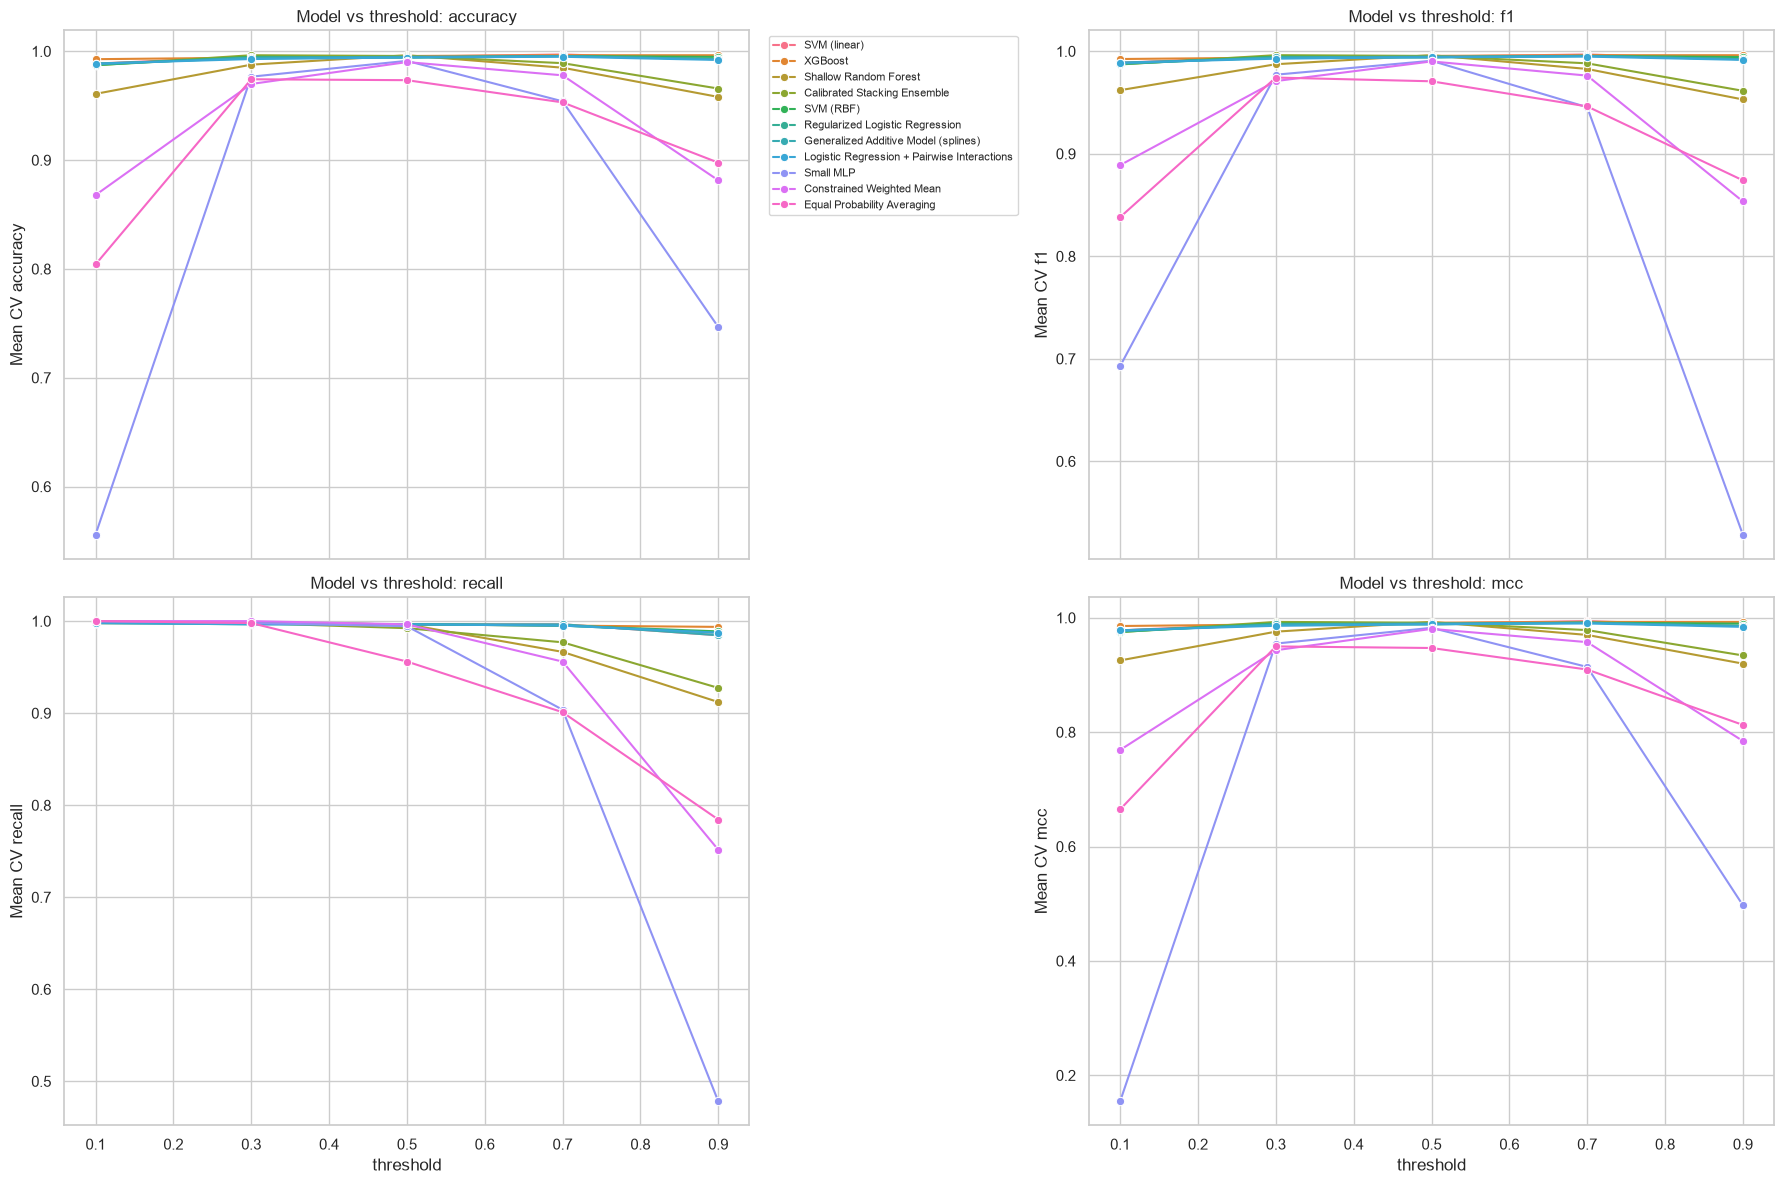

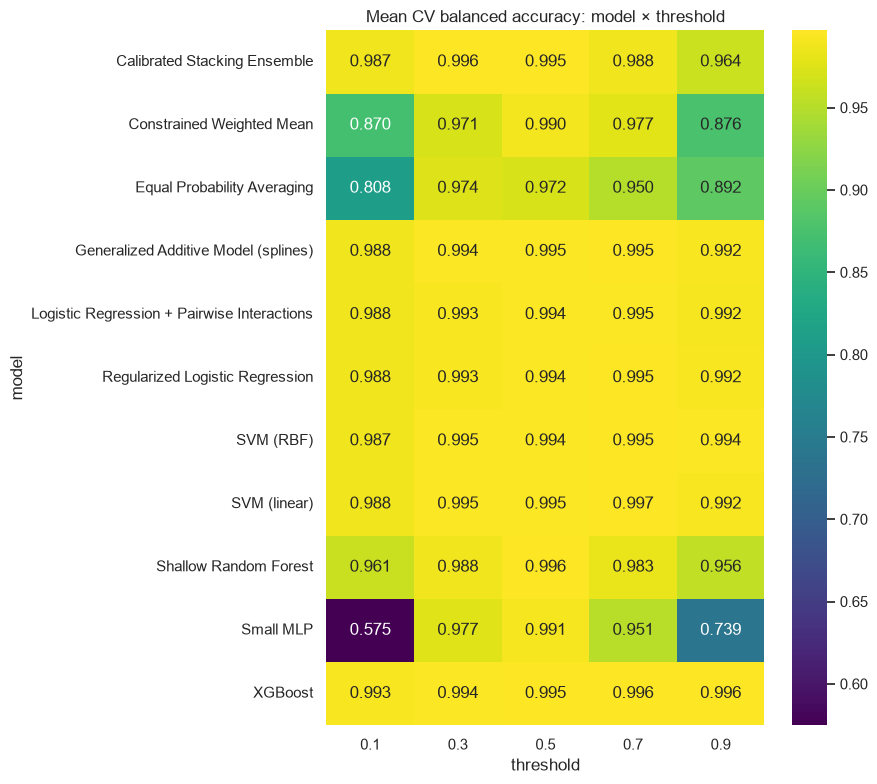

In [28]:
plot_metrics = ["accuracy", "f1", "recall", "mcc"]
fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharex=True)
for ax, metric in zip(axes.ravel(), plot_metrics):
    sns.lineplot(data=cv_summary, x="threshold", y=f"mean_{metric}", hue="model", marker="o", ax=ax)
    ax.set_title(f"Model vs threshold: {metric}"); ax.set_ylabel(f"Mean CV {metric}")
    if ax is not axes.ravel()[0]: ax.legend_.remove()
axes.ravel()[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "threshold_metric_curves.png", dpi=160, bbox_inches="tight"); plt.show()

heat = cv_summary.pivot(index="model", columns="threshold", values="mean_balanced_accuracy")
plt.figure(figsize=(9, 8)); sns.heatmap(heat, annot=True, fmt=".3f", cmap="viridis")
plt.title("Mean CV balanced accuracy: model × threshold"); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "model_threshold_heatmap.png", dpi=160, bbox_inches="tight"); plt.show()

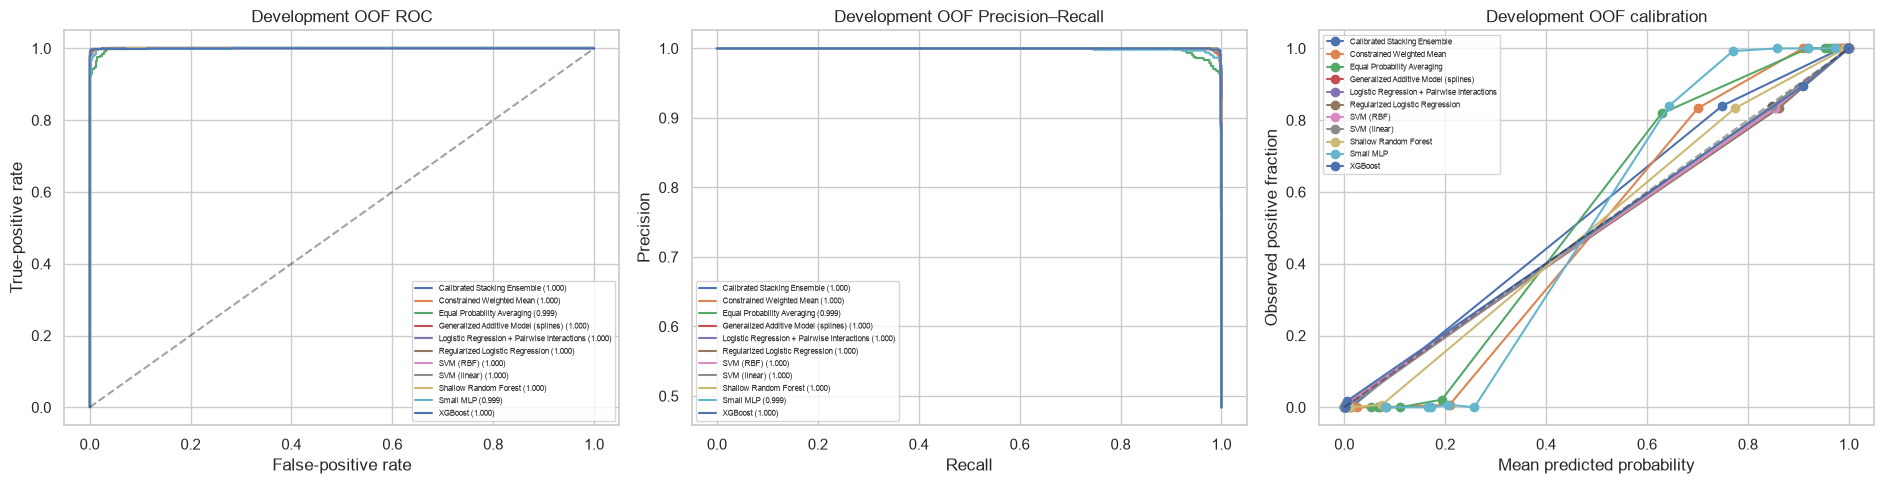

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
for name, part in cv_predictions.groupby("model"):
    fpr, tpr, _ = roc_curve(part.truth, part.probability)
    precision, recall, _ = precision_recall_curve(part.truth, part.probability)
    axes[0].plot(fpr, tpr, label=f"{name} ({roc_auc_score(part.truth, part.probability):.3f})")
    axes[1].plot(recall, precision, label=f"{name} ({average_precision_score(part.truth, part.probability):.3f})")
    frac_pos, mean_pred = calibration_curve(part.truth, part.probability, n_bins=10, strategy="quantile")
    axes[2].plot(mean_pred, frac_pos, marker="o", label=name)
axes[0].plot([0,1],[0,1],"k--",alpha=.4); axes[2].plot([0,1],[0,1],"k--",alpha=.4)
axes[0].set(title="Development OOF ROC", xlabel="False-positive rate", ylabel="True-positive rate")
axes[1].set(title="Development OOF Precision–Recall", xlabel="Recall", ylabel="Precision")
axes[2].set(title="Development OOF calibration", xlabel="Mean predicted probability", ylabel="Observed positive fraction")
for ax in axes: ax.legend(fontsize=6)
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "oof_probability_curves.png", dpi=160, bbox_inches="tight"); plt.show()

## 11. Final model selection

The automatic rule below maximizes mean CV balanced accuracy, then uses lower mean CV log loss as a tie-breaker. Set both overrides to explicit values to make a manual choice. Neither choice consults the final test set.

In [41]:
def inspect_fusion_model(model, model_name, best_params, threshold, X_reference=None, y_reference=None):
    """Show tuned settings, fitted checkpoints/formula, and feature importance."""
    report = {"model": model_name, "threshold": threshold, "best_params": best_params}
    print(f"Model: {model_name}")
    print(f"Classification threshold: {threshold:.3f}")
    print("Tuned hyperparameters:")
    display(pd.Series(best_params or {"fixed_configuration": True}, name="value").to_frame())

    if model_name == "Equal Probability Averaging":
        weights = np.repeat(1 / len(FEATURE_COLUMNS), len(FEATURE_COLUMNS))
    else:
        weights = getattr(model, "weights_", None)
    if weights is not None:
        table = pd.DataFrame({"feature": FEATURE_COLUMNS, "weight": weights})
        table["importance_share"] = table.weight.abs() / table.weight.abs().sum()
        display(table.sort_values("importance_share", ascending=False))
        formula = "p_final = " + " + ".join(
            f"({weight:.8f} × {feature})" for feature, weight in zip(FEATURE_COLUMNS, weights))
        print(formula)
        report.update(weight_table=table, formula=formula)
        return report

    # Unwrap calibrated models, FrozenEstimator, and sklearn pipelines.
    inspected = getattr(model, "estimator", model)
    inspected = getattr(inspected, "estimator", inspected)
    pipeline = inspected if hasattr(inspected, "named_steps") else None
    steps = pipeline.named_steps if pipeline is not None else {}
    fitted = steps.get("model", steps.get("meta", inspected))
    scaler = steps.get("scale")

    if isinstance(fitted, SVC) and fitted.kernel == "linear":
        standardized_weights = fitted.coef_[0]
        original_weights = standardized_weights / scaler.scale_
        original_intercept = float(
            fitted.intercept_[0] - np.dot(standardized_weights, scaler.mean_ / scaler.scale_))
        table = pd.DataFrame({
            "feature": FEATURE_COLUMNS,
            "standardized_weight": standardized_weights,
            "original_input_weight": original_weights,
        })
        table["absolute_weight"] = table.original_input_weight.abs()
        table["importance_share"] = table.absolute_weight / table.absolute_weight.sum()
        display(table.sort_values("importance_share", ascending=False))
        formula = f"decision_score = {original_intercept:.8f}" + "".join(
            f" {weight:+.8f} × ({feature})"
            for feature, weight in zip(FEATURE_COLUMNS, original_weights))
        print("Full formula using the original three probability inputs:")
        print(formula)
        print("The SVM boundary predicts class 1 when decision_score >= 0.")
        print("predict_proba then applies Platt calibration; parameters:")
        print({"probA": fitted.probA_.tolist(), "probB": fitted.probB_.tolist()})
        report.update(weight_table=table, intercept=original_intercept, formula=formula,
                      probA=fitted.probA_.copy(), probB=fitted.probB_.copy())
        return report

    if hasattr(fitted, "coef_"):
        names = list(FEATURE_COLUMNS)
        if "interactions" in steps:
            names = list(steps["interactions"].get_feature_names_out(FEATURE_COLUMNS))
        if "splines" in steps:
            names = [f"spline_term_{i}" for i in range(fitted.coef_.shape[1])]
        if scaler is not None:
            coefficients = fitted.coef_[0] / scaler.scale_
            intercept = float(fitted.intercept_[0] - np.dot(fitted.coef_[0], scaler.mean_ / scaler.scale_))
        else:
            coefficients = fitted.coef_[0]
            intercept = float(fitted.intercept_[0])
        table = pd.DataFrame({"feature_or_term": names, "coefficient": coefficients})
        table["absolute_coefficient"] = table.coefficient.abs()
        table["importance_share"] = table.absolute_coefficient / table.absolute_coefficient.sum()
        display(table.sort_values("importance_share", ascending=False))
        formula = f"log_odds = {intercept:.8f}" + "".join(
            f" {coefficient:+.8f} × ({name})" for name, coefficient in zip(names, coefficients))
        print("Coefficient formula (GAM names refer to spline-basis terms):")
        print(formula)
        report.update(coefficient_table=table, intercept=intercept, formula=formula)
        return report

    if hasattr(fitted, "feature_importances_"):
        table = pd.DataFrame({"feature": FEATURE_COLUMNS, "importance": fitted.feature_importances_})
        display(table.sort_values("importance", ascending=False))
        report["feature_importance"] = table
        return report

    if hasattr(fitted, "coefs_"):
        first_layer = np.abs(fitted.coefs_[0]).sum(axis=1)
        table = pd.DataFrame({"feature": FEATURE_COLUMNS, "first_layer_absolute_weight": first_layer})
        table["importance_share"] = table.first_layer_absolute_weight / table.first_layer_absolute_weight.sum()
        display(table.sort_values("importance_share", ascending=False))
        for layer, (layer_weights, layer_bias) in enumerate(zip(fitted.coefs_, fitted.intercepts_)):
            print(f"MLP layer {layer}: weights={layer_weights.shape}, bias={layer_bias.shape}")
            display(pd.DataFrame(layer_weights))
        report.update(input_importance=table, layer_weights=fitted.coefs_)
        return report

    if X_reference is not None and y_reference is not None:
        from sklearn.inspection import permutation_importance
        permutation = permutation_importance(
            model, X_reference, y_reference, scoring="neg_log_loss",
            n_repeats=20, random_state=SEED, n_jobs=N_JOBS)
        table = pd.DataFrame({"feature": FEATURE_COLUMNS,
                              "importance_mean": permutation.importances_mean,
                              "importance_sd": permutation.importances_std})
        display(table.sort_values("importance_mean", ascending=False))
        report["permutation_importance"] = table
    return report


Model: SVM (linear)
Classification threshold: 0.700
Tuned hyperparameters:


/Users/dunglai/Desktop/Việt Dũng/Hackathon/Tiktok/Coding/.venv/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/dunglai/Desktop/Việt Dũng/Hackathon/Tiktok/Coding/.venv/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/dunglai/Desktop/Việt Dũng/Hackathon/Tiktok/Coding/.venv/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/dunglai/Desk

,value
model__C,0.1


,feature,standardized_weight,original_input_weight,absolute_weight,importance_share
1,DINOv3-L detector Pr,1.608140,3.685514,3.685514,0.635131
2,DINOv3-B stacking detector Pr,0.661650,1.893027,1.893027,0.326229
0,Community Forensics Pr,0.107673,0.224218,0.224218,0.038640


Full formula using the original three probability inputs:
decision_score = -3.13437199 +0.22421767 × (Community Forensics Pr) +3.68551361 × (DINOv3-L detector Pr) +1.89302683 × (DINOv3-B stacking detector Pr)
The SVM boundary predicts class 1 when decision_score >= 0.
predict_proba then applies Platt calibration; parameters:
{'probA': [-3.4560131705160173], 'probB': [-0.38512945888560696]}


/Users/dunglai/Desktop/Việt Dũng/Hackathon/Tiktok/Coding/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:109: FutureWarning: Attribute `probA_` was deprecated in version 1.9 and will be removed in 1.11 as the `probability=True` option for SVC and NuSVC was deprecated and will be removed in 1.11.
  warnings.warn(msg, category=FutureWarning)
/Users/dunglai/Desktop/Việt Dũng/Hackathon/Tiktok/Coding/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:109: FutureWarning: Attribute `probB_` was deprecated in version 1.9 and will be removed in 1.11 as the `probability=True` option for SVC and NuSVC was deprecated and will be removed in 1.11.
  warnings.warn(msg, category=FutureWarning)


,value
model,SVM (linear)
threshold,0.7
rows,2000
evaluation_scope,all_rows_mixed_in_sample_and_holdout
accuracy,0.9905
precision,1.0
recall,0.981
specificity,1.0
f1,0.990409
balanced_accuracy,0.9905


Confusion matrix [[TN, FP], [FN, TP]]:


,Predicted 0,Predicted 1
Actual 0,1000,0
Actual 1,19,981


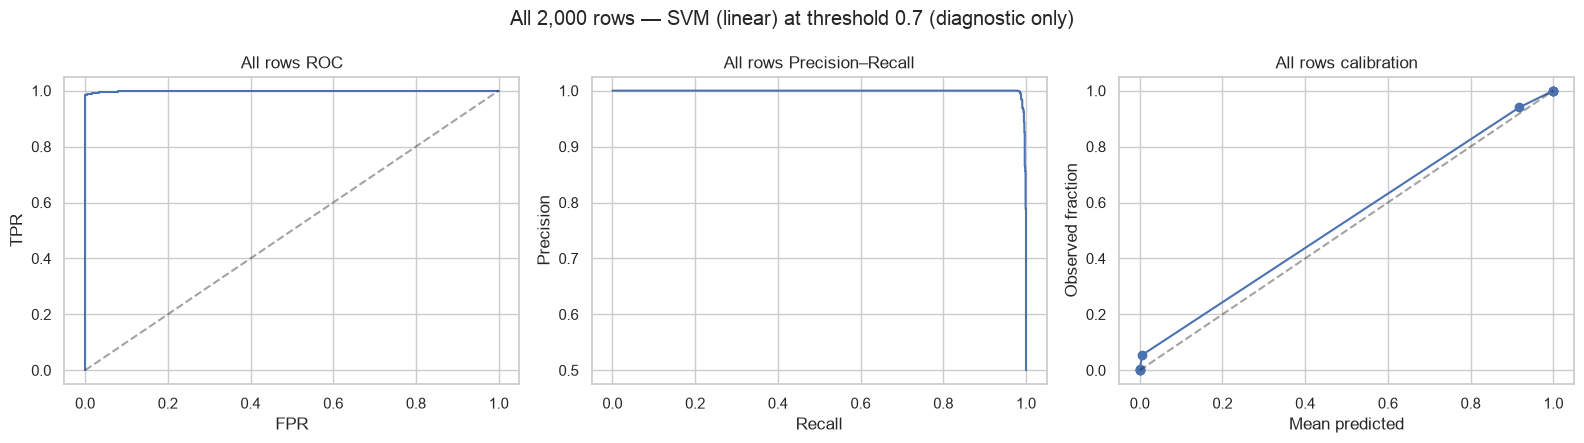

In [42]:
FINAL_MODEL = "SVM (linear)"
FINAL_THRESHOLD = 0.7   

final_model, final_best_params = fit_candidate(FINAL_MODEL, X_dev, y_dev, groups_dev, seed=SEED)

artifact_path = OUTPUT_DIR / "selected_final_fusion.joblib"
joblib.dump({"model": final_model, "model_name": FINAL_MODEL,
             "threshold": FINAL_THRESHOLD, "feature_order": FEATURE_COLUMNS,
             "best_params": final_best_params}, artifact_path)
(OUTPUT_DIR / "selected_final_fusion.json").write_text(json.dumps({
    "model": FINAL_MODEL, "threshold": FINAL_THRESHOLD,
    "feature_order": FEATURE_COLUMNS, "best_params": final_best_params,
    "development_rows": int(len(dev_idx)), "final_test_rows": int(len(final_test_idx)),
    "random_state": SEED, "group_source": group_source,
}, indent=2, default=str) + "\n")
print("Saved selected fusion artifact:", artifact_path)

model_details = inspect_fusion_model(
    final_model, FINAL_MODEL, final_best_params, FINAL_THRESHOLD, X_dev, y_dev)

all_probability = final_model.predict_proba(X)[:, 1]
all_values = {"model": FINAL_MODEL, "threshold": FINAL_THRESHOLD,
              "rows": int(len(y)), "evaluation_scope": "all_rows_mixed_in_sample_and_holdout",
              **threshold_metrics(y, all_probability, FINAL_THRESHOLD),
              **probability_metrics(y, all_probability)}
all_rows_results = pd.DataFrame([all_values])
all_rows_predictions = pd.DataFrame({
    "original_row": np.arange(len(y)),
    "partition": np.where(np.isin(np.arange(len(y)), final_test_idx), "final_test", "development"),
    "truth": y,
    "probability": all_probability,
    "prediction": (all_probability >= FINAL_THRESHOLD).astype(int),
})
all_rows_results.to_csv(OUTPUT_DIR / "all_2000_rows_diagnostic_results.csv", index=False)
all_rows_predictions.to_csv(OUTPUT_DIR / "all_2000_rows_predictions.csv", index=False)
display(all_rows_results.T.rename(columns={0: "value"}))
print("Confusion matrix [[TN, FP], [FN, TP]]:")
display(pd.DataFrame([[all_values["tn"], all_values["fp"]],
                      [all_values["fn"], all_values["tp"]]],
                     index=["Actual 0", "Actual 1"], columns=["Predicted 0", "Predicted 1"]))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fpr, tpr, _ = roc_curve(y, all_probability)
precision, recall, _ = precision_recall_curve(y, all_probability)
frac_pos, mean_pred = calibration_curve(y, all_probability, n_bins=10, strategy="quantile")
axes[0].plot(fpr, tpr); axes[0].plot([0, 1], [0, 1], "k--", alpha=.4); axes[0].set(title="All rows ROC", xlabel="FPR", ylabel="TPR")
axes[1].plot(recall, precision); axes[1].set(title="All rows Precision–Recall", xlabel="Recall", ylabel="Precision")
axes[2].plot(mean_pred, frac_pos, marker="o"); axes[2].plot([0, 1], [0, 1], "k--", alpha=.4); axes[2].set(title="All rows calibration", xlabel="Mean predicted", ylabel="Observed fraction")
fig.suptitle(f"All {len(y):,} rows — {FINAL_MODEL} at threshold {FINAL_THRESHOLD:.1f} (diagnostic only)")
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "all_2000_rows_diagnostic_curves.png", dpi=160, bbox_inches="tight"); plt.show()